# Notebook 03 — Análisis de Engagement en Bloque Neón
### Sistema de Alerta Temprana · IIND-2104 Modelos Probabilísticos
**Universidad de los Andes**

---

## Propósito de este notebook

El **engagement** en la plataforma Bloque Neón representa la huella digital de estudio de cada estudiante. A diferencia de las notas, estas métricas están disponibles de forma continua, lo que las convierte en candidatas naturales para alimentar **alertas tempranas**, incluso antes de que ocurra el primer parcial ($P_1$).

Este notebook busca responder tres preguntas fundamentales:

1. **¿Cuánto estudian los estudiantes en la plataforma?** Análisis de distribuciones de tiempo, visitas y amplitud temática.
2. **¿Difiere el engagement entre APROBÓ y REPROBÓ?** Aplicación de pruebas estadísticas y cálculo de tamaños de efecto.
3. **¿El engagement aporta información más allá de las notas?** Evaluación del valor incremental del engagement como predictor de éxito académico.

---

## Subconjuntos de Datos Utilizados

| Subset | $N$ | Descripción |
| :--- | :---: | :--- |
| `df_activos_engagement` | 502 | Estudiantes con engagement $> 0$. Incluye **APROBÓ** (373) y **REPROBÓ** (129). |
| `df_activos` | 554 | Referencia completa. Incluye a los 52 estudiantes activos con engagement nulo. |

> [!IMPORTANT]
> **Recordatorio Crítico:** Los 52 estudiantes activos con engagement $= 0$ se excluyen de `df_activos_engagement` para evitar sesgar las distribuciones. Sin embargo, en el sistema de alertas, el **engagement nulo es una señal de riesgo extremo**, no un dato faltante.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.stats import gaussian_kde, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

# ── Paleta consistente con notebooks anteriores ───────────────────────────────
PALETA_ESTADO = {'APROBÓ': '#2ecc71', 'REPROBÓ': '#e74c3c'}
PALETA_ERA    = {'formato_antiguo': '#2c3e50', 'formato_nuevo': '#e67e22'}
PALETA_SEMESTRE = {
    202320: '#1a3a5c', 202410: '#2471a3',
    202420: '#e67e22', 202510: '#ca6f1e', 202520: '#784212',
}

plt.rcParams.update({
    'figure.dpi': 150, 'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa', 'axes.grid': True,
    'grid.color': 'white', 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 12, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
})

# ── Carga de datos ────────────────────────────────────────────────────────────
df_ae      = pd.read_csv('../data/subsets/df_activos_engagement.csv')
df_activos = pd.read_csv('../data/subsets/df_activos.csv')

df_ae['semestre']      = df_ae['semestre'].astype(int)
df_activos['semestre'] = df_activos['semestre'].astype(int)
semestres = sorted(df_ae['semestre'].unique())

print(f"df_activos_engagement: {df_ae.shape}")
print(f"APROBÓ: {(df_ae['estado']=='APROBÓ').sum()} | REPROBÓ: {(df_ae['estado']=='REPROBÓ').sum()}")
print(f"Verificación engagement > 0: {(df_ae['engagement_hasta_p1'] == 0).sum()} casos con engagement=0")

df_activos_engagement: (502, 77)
APROBÓ: 373 | REPROBÓ: 129
Verificación engagement > 0: 0 casos con engagement=0


## Sección 1 — Variables de Engagement: Overview

Las variables de engagement se agrupan en tres familias principales para el análisis de la "huella digital" del estudiante:

| Familia | Variables | Checkpoint disponible |
| :--- | :--- | :--- |
| **Tiempo acumulado** | `engagement_hasta_p1/p2/p3` (hrs) | CP1, CP2, CP3 |
| **Granular CP1** | `parcial_1_tiempo_hrs`, `_visitas`, `_temas_unicos`, `_modulos_unicos`, `_visitas_por_tema`, `_tiempo_por_visita` | CP1 |
| **Total semestre** | `total_tiempo_hrs`, `total_visitas`, `total_temas`, `total_modulos`, `promedio_tiempo_por_visita` | CP3 / Retrospectivo |
| **Actividades** | `actividades_tiempo_total`, `actividades_visitas_total`, `actividades_n_realizadas` | CP1 / CP2 |

---

### ⚠️ Observación Estructural Importante

Existe una **correlación perfecta ($r = 1.0$)** entre las variables `engagement_hasta_p1` y `parcial_1_tiempo_hrs`. 

> **Razón:** El tiempo acumulado registrado hasta el primer corte ($P_1$) es, por definición, idéntico al tiempo dedicado específicamente al contenido evaluado en dicho parcial. Se debe tener cuidado de no incluirlas simultáneamente en modelos de regresión para evitar problemas de **multicolinealidad**.

---

### 1.1 Estadísticos descriptivos de engagement por estado
*(A continuación se presentan las métricas comparativas entre estudiantes que Aprobaron vs. Reprobaron)*

In [2]:
eng_vars = {
    'engagement_hasta_p1':        'Tiempo hasta P1 (hrs) [CP1]',
    'parcial_1_visitas':          'Visitas contenido P1 [CP1]',
    'parcial_1_temas_unicos':     'Temas únicos P1 [CP1]',
    'parcial_1_modulos_unicos':   'Módulos únicos P1 [CP1]',
    'parcial_1_visitas_por_tema': 'Visitas por tema P1 [CP1]',
    'parcial_1_tiempo_por_visita':'Minutos por visita P1 [CP1]',
    'engagement_hasta_p2':        'Tiempo hasta P2 (hrs) [CP2]',
    'engagement_hasta_p3':        'Tiempo total semestre (hrs) [CP3]',
    'total_visitas':              'Visitas totales semestre [CP3]',
    'total_temas':                'Temas únicos semestre [CP3]',
    'total_modulos':              'Módulos únicos semestre [CP3]',
    'promedio_tiempo_por_visita': 'Minutos/visita promedio [CP3]',
}

print("=" * 85)
print("ESTADÍSTICOS DE ENGAGEMENT POR ESTADO (df_activos_engagement)")
print("=" * 85)
print(f"{'Variable':<40} {'Med APROBÓ':>12} {'Med REPROBÓ':>12} {'p-valor':>10} {'Sig':>5}")
print("-" * 85)

for var, label in eng_vars.items():
    apro  = df_ae[df_ae['estado']=='APROBÓ'][var].dropna()
    repr_ = df_ae[df_ae['estado']=='REPROBÓ'][var].dropna()
    if len(apro) < 5 or len(repr_) < 5: continue
    u, p = mannwhitneyu(apro, repr_, alternative='two-sided')
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    print(f"  {label:<38} {apro.median():>12.2f} {repr_.median():>12.2f} {p:>10.4f} {sig:>5}")

print("-" * 85)
print("\nPrueba: Mann-Whitney U bilateral | * p<0.05 | ** p<0.01 | *** p<0.001")
print("Nota: Variables de actividades (actividades_n_realizadas, _tiempo_total, _visitas_total)")
print("      NO muestran diferencias significativas (p>0.05) → bajo poder discriminante")

ESTADÍSTICOS DE ENGAGEMENT POR ESTADO (df_activos_engagement)
Variable                                   Med APROBÓ  Med REPROBÓ    p-valor   Sig
-------------------------------------------------------------------------------------
  Tiempo hasta P1 (hrs) [CP1]                    8.27         5.71     0.0006   ***
  Visitas contenido P1 [CP1]                    37.00        32.00     0.0111     *
  Temas únicos P1 [CP1]                         12.00        11.00     0.0229     *
  Módulos únicos P1 [CP1]                        7.00         6.00     0.0005   ***
  Visitas por tema P1 [CP1]                      3.20         2.83     0.0276     *
  Minutos por visita P1 [CP1]                   12.26        11.07     0.0349     *
  Tiempo hasta P2 (hrs) [CP2]                   16.23        11.26     0.0009   ***
  Tiempo total semestre (hrs) [CP3]             22.61        16.96     0.0005   ***
  Visitas totales semestre [CP3]               235.00       197.00     0.0073    **
  Temas únic

## Sección 2 — Distribuciones de Engagement: CP1
El Checkpoint 1 (semana 6) es el momento de intervención más temprano y valioso. Las variables disponibles aquí son las del contenido relacionado con el Parcial 1: tiempo invertido, amplitud de exploración (temas, módulos) y profundidad de revisión (visitas por tema, minutos por visita).
El hallazgo central: todas las variables de engagement en CP1 son estadísticamente significativas (p<0.05) en discriminar APROBÓ de REPROBÓ, aunque con tamaños de efecto modestos (r_biserial entre 0.10 y 0.16). El tiempo y la amplitud temática son más discriminativos que la profundidad por visita.
## 2.1 Distribuciones de las 4 variables clave de CP1 por estado

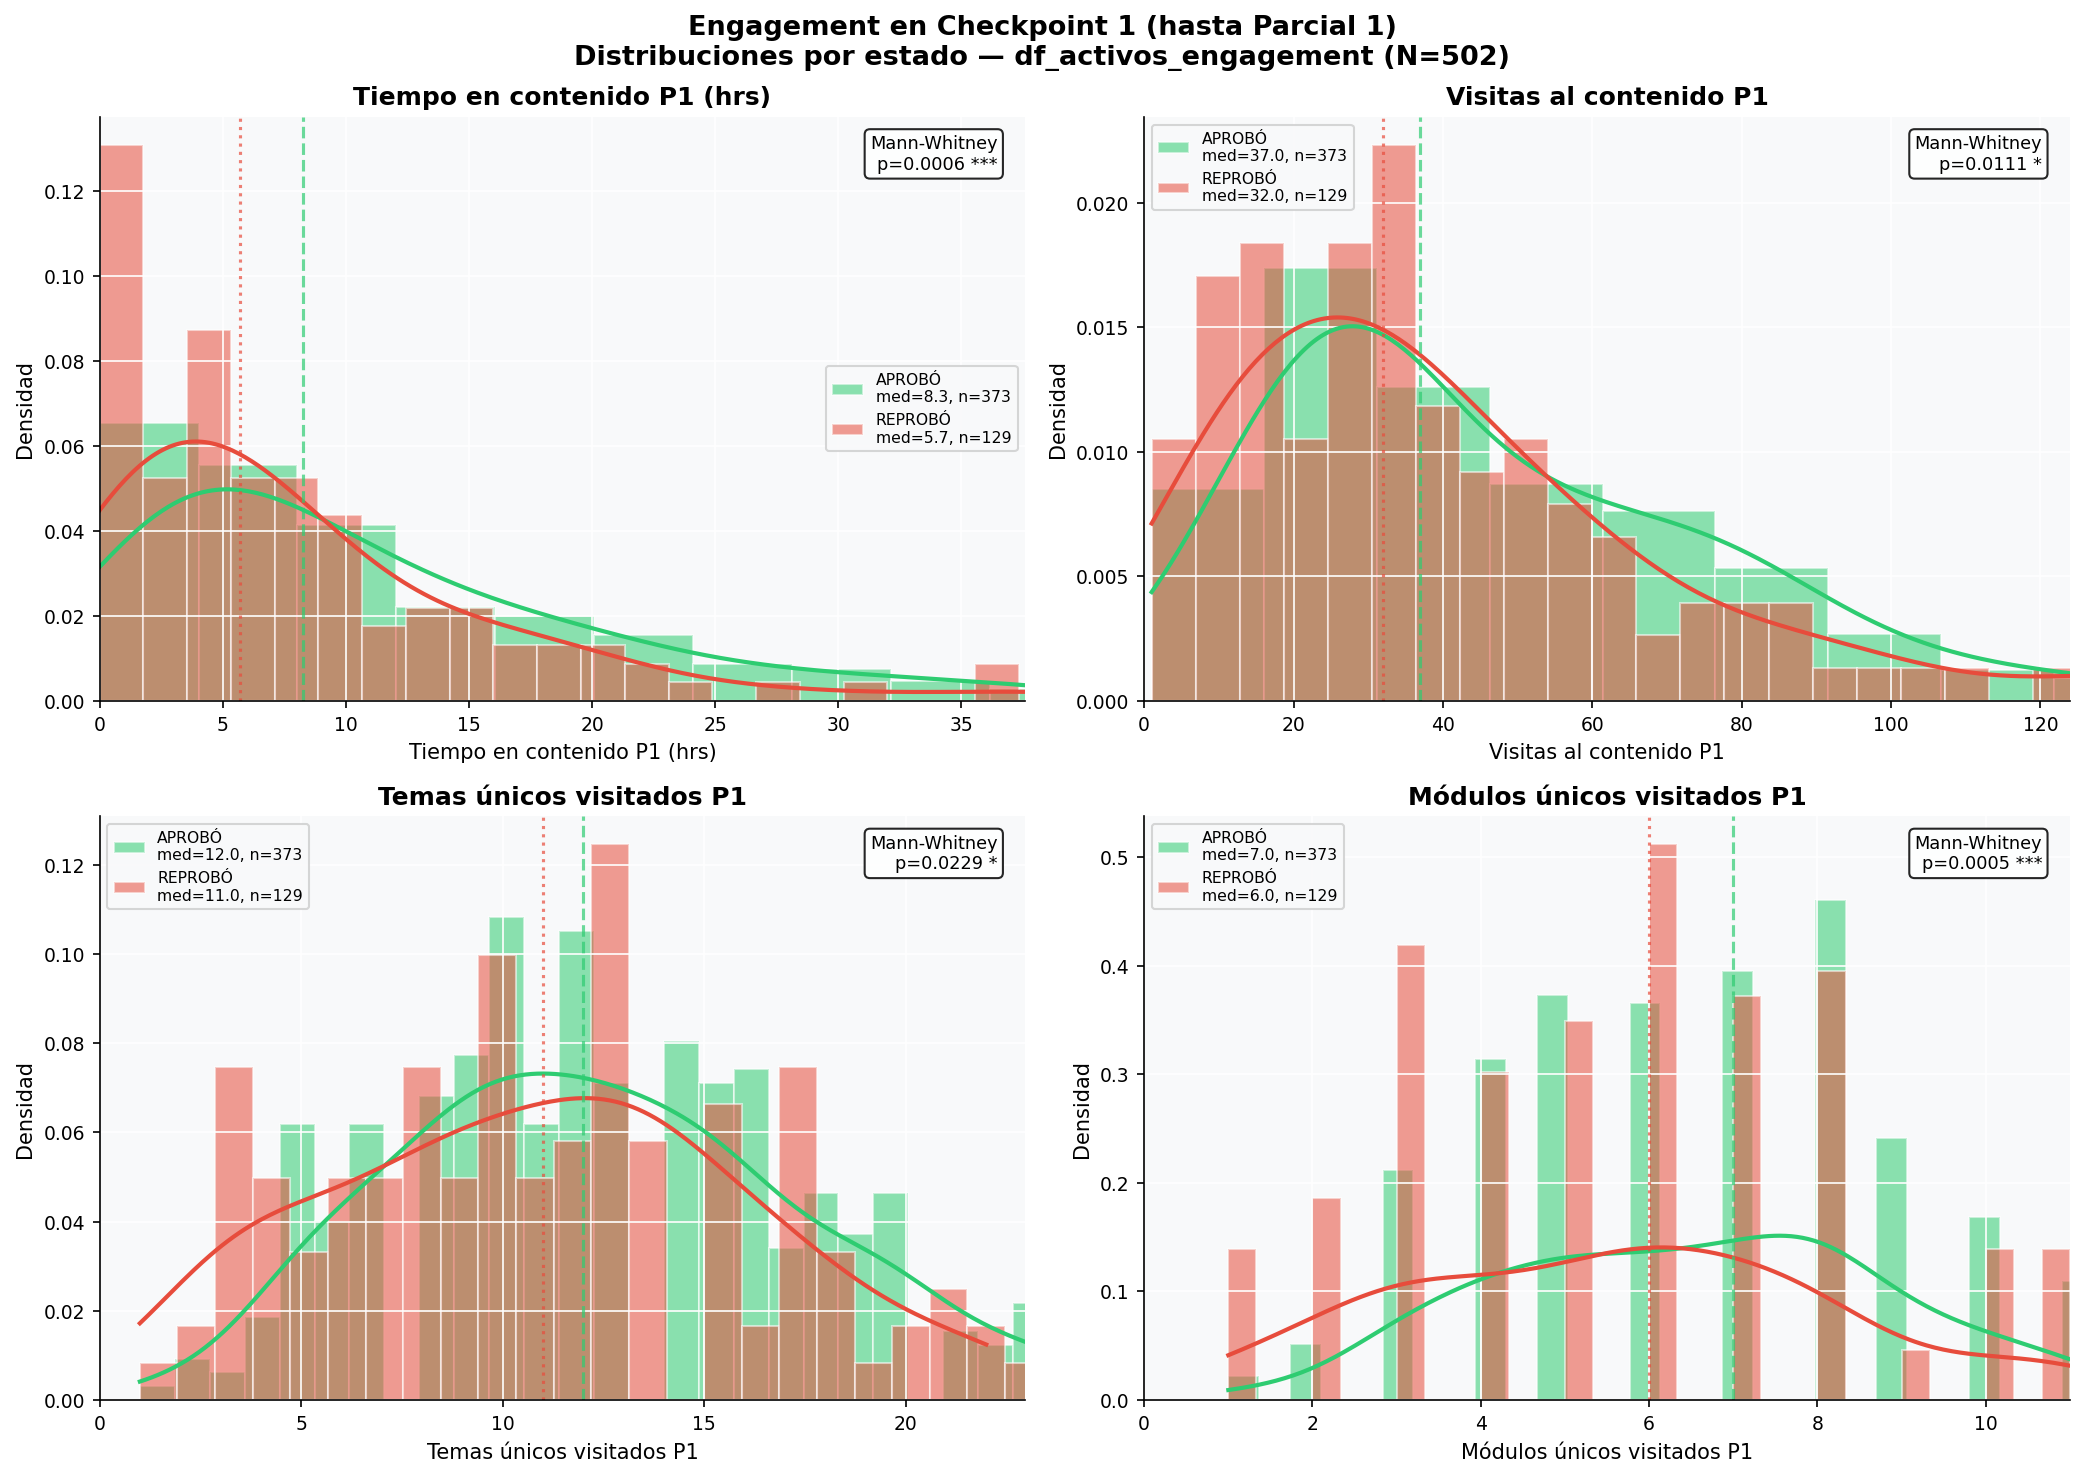

In [3]:
vars_cp1 = [
    ('engagement_hasta_p1',       'Tiempo en contenido P1 (hrs)', False),
    ('parcial_1_visitas',         'Visitas al contenido P1', False),
    ('parcial_1_temas_unicos',    'Temas únicos visitados P1', False),
    ('parcial_1_modulos_unicos',  'Módulos únicos visitados P1', False),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Engagement en Checkpoint 1 (hasta Parcial 1)\nDistribuciones por estado — df_activos_engagement (N=502)',
             fontsize=13, fontweight='bold')

for ax, (var, xlabel, logscale) in zip(axes.flat, vars_cp1):
    for estado in ['APROBÓ', 'REPROBÓ']:
        data = df_ae[df_ae['estado'] == estado][var].dropna()
        ax.hist(data, bins=30, alpha=0.55, color=PALETA_ESTADO[estado],
                label=f'{estado}\nmed={data.median():.1f}, n={len(data)}',
                edgecolor='white', density=True)
        if len(data) > 10:
            kde_x = np.linspace(data.min(), data.quantile(0.98), 300)
            try:
                ax.plot(kde_x, gaussian_kde(data)(kde_x), color=PALETA_ESTADO[estado], linewidth=2)
            except: pass

    # Mediana vertical
    for estado, ls in [('APROBÓ', '--'), ('REPROBÓ', ':')]:
        med = df_ae[df_ae['estado']==estado][var].median()
        ax.axvline(med, color=PALETA_ESTADO[estado], linestyle=ls, linewidth=1.5, alpha=0.7)

    # Test estadístico
    apro  = df_ae[df_ae['estado']=='APROBÓ'][var].dropna()
    repr_ = df_ae[df_ae['estado']=='REPROBÓ'][var].dropna()
    u, p  = mannwhitneyu(apro, repr_, alternative='two-sided')
    sig   = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    ax.text(0.97, 0.97, f'Mann-Whitney\np={p:.4f} {sig}',
            transform=ax.transAxes, va='top', ha='right', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

    ax.set_xlabel(xlabel); ax.set_ylabel('Densidad')
    ax.set_xlim(0, df_ae[var].quantile(0.97))
    ax.set_title(f'{xlabel}', fontweight='bold')
    ax.legend(fontsize=7.5)

plt.tight_layout()
plt.savefig('../figures/03_engagement_cp1_distribuciones.png', bbox_inches='tight', dpi=150)
plt.show()

### 2.2 Boxplots comparativos por estado y semestre

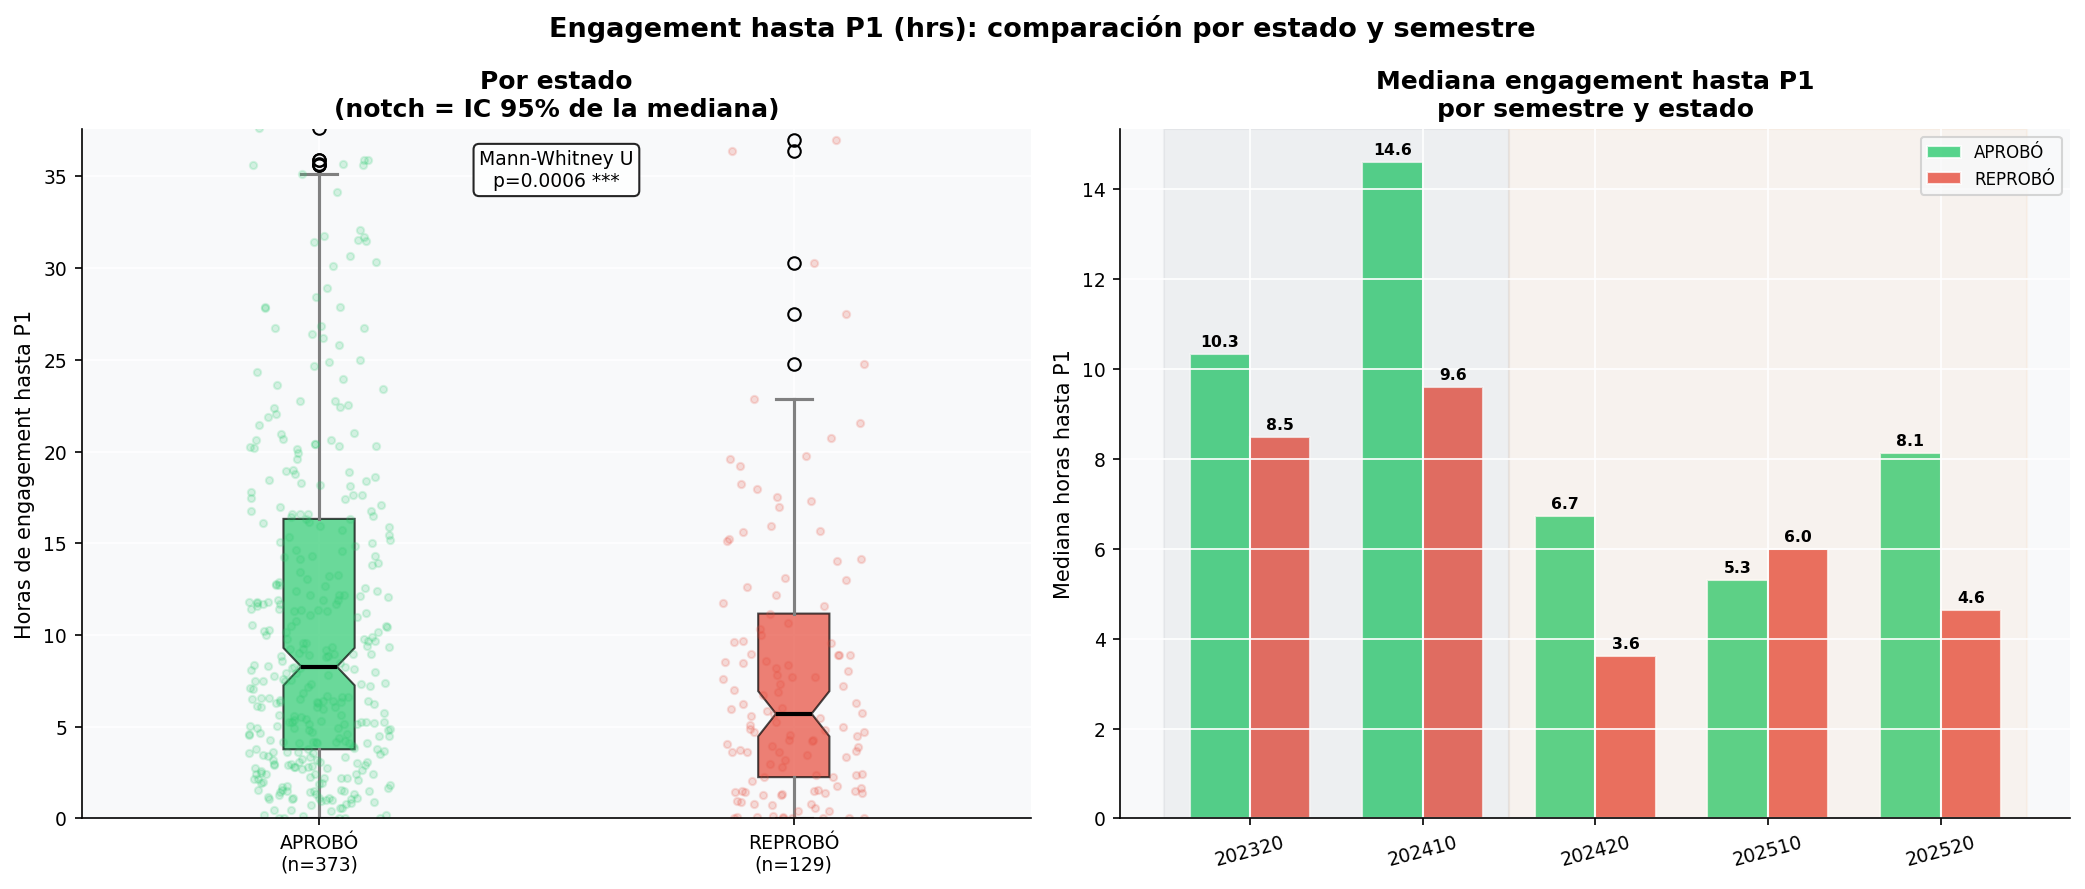

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Engagement hasta P1 (hrs): comparación por estado y semestre',
             fontsize=13, fontweight='bold')

# ── Panel A: Boxplot APROBÓ vs REPROBÓ ───────────────────────────────────────
ax = axes[0]
data_box = [df_ae[df_ae['estado']==e]['engagement_hasta_p1'].dropna().values
            for e in ['APROBÓ', 'REPROBÓ']]
bp = ax.boxplot(data_box, patch_artist=True, notch=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], [PALETA_ESTADO['APROBÓ'], PALETA_ESTADO['REPROBÓ']]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
for whisker in bp['whiskers']: whisker.set(color='gray', linewidth=1.5)
for cap in bp['caps']:         cap.set(color='gray', linewidth=1.5)

# Añadir jitter
for i, estado in enumerate(['APROBÓ', 'REPROBÓ']):
    data = df_ae[df_ae['estado']==estado]['engagement_hasta_p1'].dropna()
    jitter = np.random.uniform(-0.15, 0.15, len(data))
    ax.scatter(np.ones(len(data))*(i+1) + jitter, data,
               alpha=0.18, s=12, color=PALETA_ESTADO[estado], zorder=2)

ax.set_xticklabels(['APROBÓ\n(n=373)', 'REPROBÓ\n(n=129)'])
ax.set_ylabel('Horas de engagement hasta P1')
ax.set_ylim(0, df_ae['engagement_hasta_p1'].quantile(0.97))
ax.set_title('Por estado\n(notch = IC 95% de la mediana)', fontweight='bold')

u, p = mannwhitneyu(
    df_ae[df_ae['estado']=='APROBÓ']['engagement_hasta_p1'].dropna(),
    df_ae[df_ae['estado']=='REPROBÓ']['engagement_hasta_p1'].dropna(),
    alternative='two-sided'
)
ax.text(0.5, 0.97, f'Mann-Whitney U\np={p:.4f} ***',
        transform=ax.transAxes, va='top', ha='center', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

# ── Panel B: Mediana por semestre y estado ────────────────────────────────────
ax2 = axes[1]
x = np.arange(len(semestres)); w = 0.35
for j, (estado, color) in enumerate([('APROBÓ', PALETA_ESTADO['APROBÓ']),
                                       ('REPROBÓ', PALETA_ESTADO['REPROBÓ'])]):
    medias = [df_ae[(df_ae['semestre']==s) & (df_ae['estado']==estado)]['engagement_hasta_p1'].median()
              for s in semestres]
    ns     = [len(df_ae[(df_ae['semestre']==s) & (df_ae['estado']==estado)]) for s in semestres]
    ax2.bar(x + j*w - w/2, medias, width=w, color=color, alpha=0.8,
            label=estado, edgecolor='white')
    for xi, (m, n) in enumerate(zip(medias, ns)):
        if not np.isnan(m):
            ax2.text(xi + j*w - w/2, m + 0.1, f'{m:.1f}',
                     ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax2.set_xticks(x); ax2.set_xticklabels([str(s) for s in semestres], rotation=15)
ax2.set_ylabel('Mediana horas hasta P1')
ax2.set_title('Mediana engagement hasta P1\npor semestre y estado', fontweight='bold')
ax2.legend(fontsize=8)
ax2.axvspan(-0.5, 1.5, alpha=0.05, color=PALETA_ERA['formato_antiguo'])
ax2.axvspan(1.5, 4.5, alpha=0.05, color=PALETA_ERA['formato_nuevo'])

plt.tight_layout()
plt.savefig('../figures/03_engagement_cp1_boxplot_semestre.png', bbox_inches='tight', dpi=150)
plt.show()

### Sección 3 — Patrones Temporales de Engagement
Una pregunta clave para el sistema de alertas es si el engagement varía a lo largo del semestre de manera distinta entre APROBÓ y REPROBÓ. Un estudiante que decrece progresivamente puede estar indicando desenganche antes de que las notas lo reflejen.
Los datos muestran que ambos grupos incrementan el engagement entre CP1 y CP2, pero el incremento es mayor para los APROBÓ. En CP3, la mediana de engagement cae notablemente (especialmente en REPROBÓ), reflejando abandono efectivo hacia el final del semestre.
### 3.1 Evolución acumulada de engagement por estado y semestre

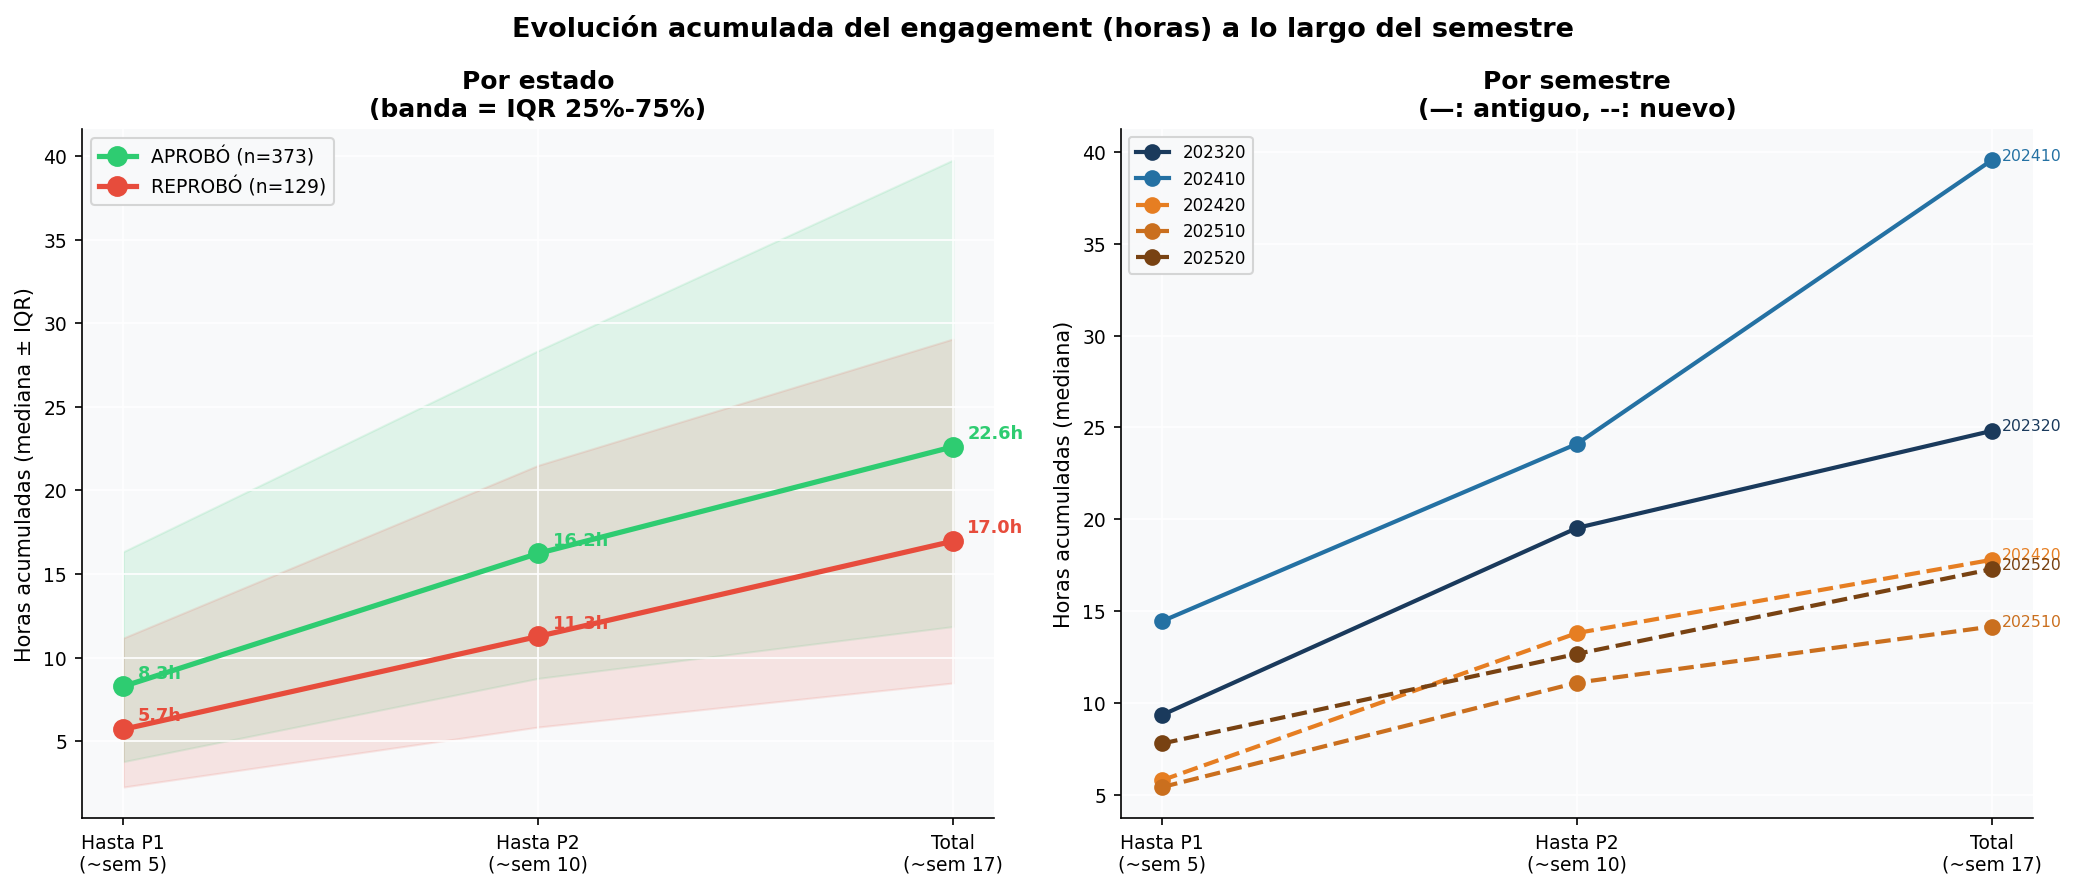

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Evolución acumulada del engagement (horas) a lo largo del semestre',
             fontsize=13, fontweight='bold')

checkpoints = ['engagement_hasta_p1', 'engagement_hasta_p2', 'engagement_hasta_p3']
labels_ck   = ['Hasta P1\n(~sem 5)', 'Hasta P2\n(~sem 10)', 'Total\n(~sem 17)']

# ── Panel A: Medianas por estado con IC ───────────────────────────────────────
ax = axes[0]
for estado in ['APROBÓ', 'REPROBÓ']:
    sub     = df_ae[df_ae['estado'] == estado]
    medianas = [sub[ck].median() for ck in checkpoints]
    p25      = [sub[ck].quantile(0.25) for ck in checkpoints]
    p75      = [sub[ck].quantile(0.75) for ck in checkpoints]

    ax.plot(range(3), medianas, 'o-', color=PALETA_ESTADO[estado],
            linewidth=2.5, markersize=9, label=f'{estado} (n={len(sub)})', zorder=3)
    ax.fill_between(range(3), p25, p75, alpha=0.12, color=PALETA_ESTADO[estado])
    for i, m in enumerate(medianas):
        ax.annotate(f'{m:.1f}h', (i, m),
                    textcoords='offset points', xytext=(7, 4),
                    fontsize=8.5, color=PALETA_ESTADO[estado], fontweight='bold')

ax.set_xticks(range(3)); ax.set_xticklabels(labels_ck)
ax.set_ylabel('Horas acumuladas (mediana ± IQR)')
ax.set_title('Por estado\n(banda = IQR 25%-75%)', fontweight='bold')
ax.legend()

# ── Panel B: Por semestre ─────────────────────────────────────────────────────
ax2 = axes[1]
for sem in semestres:
    sub     = df_ae[df_ae['semestre'] == sem]
    era     = sub['era'].iloc[0]
    medianas = [sub[ck].median() for ck in checkpoints]
    ls       = '-' if era == 'formato_antiguo' else '--'
    ax2.plot(range(3), medianas, 'o'+ls, color=PALETA_SEMESTRE[sem],
             linewidth=2, markersize=7, label=str(sem))
    ax2.annotate(str(sem), (2, medianas[2]),
                 textcoords='offset points', xytext=(5, 0),
                 fontsize=7.5, color=PALETA_SEMESTRE[sem])

ax2.set_xticks(range(3)); ax2.set_xticklabels(labels_ck)
ax2.set_ylabel('Horas acumuladas (mediana)')
ax2.set_title('Por semestre\n(—: antiguo, --: nuevo)', fontweight='bold')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../figures/03_evolucion_engagement_temporal.png', bbox_inches='tight', dpi=150)
plt.show()

### 3.2 Incremento entre checkpoints: ¿quiénes mantienen el ritmo?
El incremento entre checkpoints es más informativo que el total acumulado porque captura la dinámica de estudio. Un decremento entre CP2 y CP3 es señal de abandono progresivo.

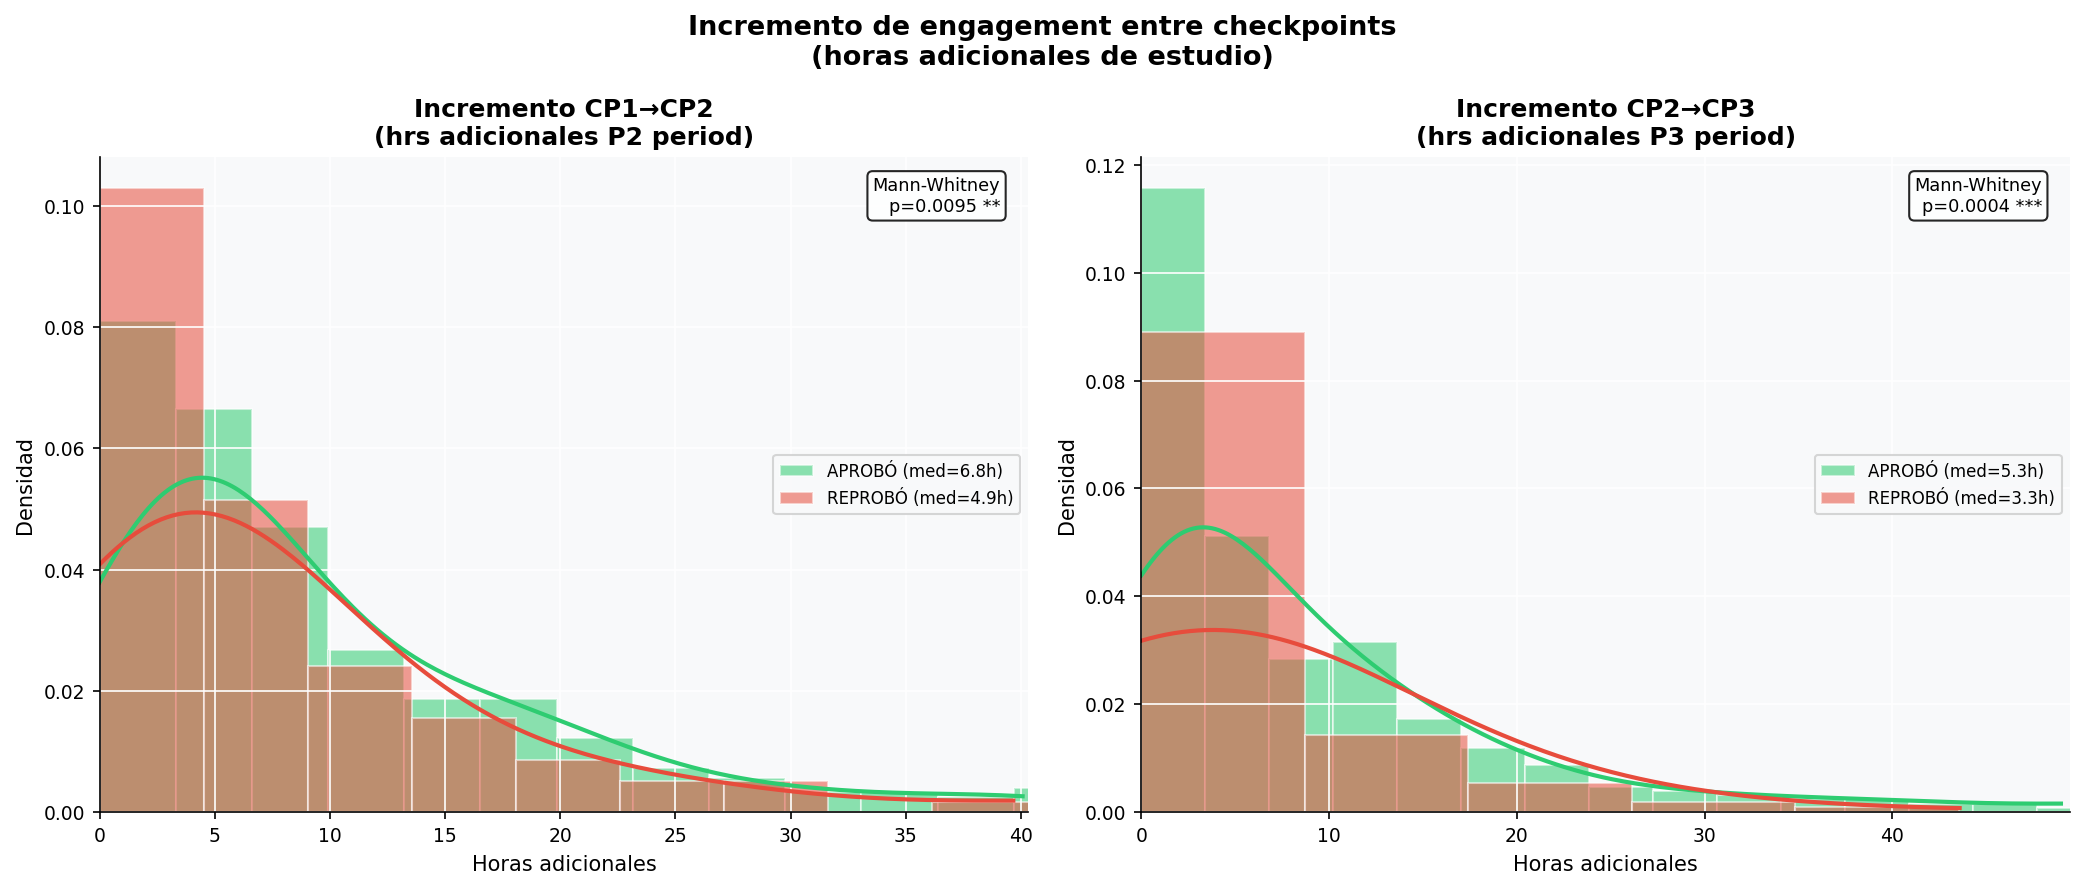


Medianas de incrementos por estado:
         delta_eng_p2_p1  delta_eng_p3_p2
estado                                   
APROBÓ              6.80             5.29
REPROBÓ             4.85             3.28

Interpretación: APROBÓ incrementa más en cada período (+6.8h vs +4.9h en P2 period)
El gap se amplía hacia el final del semestre.


In [6]:
df_ae['delta_eng_p2_p1'] = df_ae['engagement_hasta_p2'] - df_ae['engagement_hasta_p1']
df_ae['delta_eng_p3_p2'] = df_ae['engagement_hasta_p3'] - df_ae['engagement_hasta_p2']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Incremento de engagement entre checkpoints\n(horas adicionales de estudio)',
             fontsize=13, fontweight='bold')

# ── Panel A: Distribución de deltas por estado ────────────────────────────────
for ax, (delta_var, titulo) in zip(axes, [
    ('delta_eng_p2_p1', 'Incremento CP1→CP2\n(hrs adicionales P2 period)'),
    ('delta_eng_p3_p2', 'Incremento CP2→CP3\n(hrs adicionales P3 period)')
]):
    for estado in ['APROBÓ', 'REPROBÓ']:
        data = df_ae[df_ae['estado'] == estado][delta_var].dropna()
        ax.hist(data, bins=30, alpha=0.55, color=PALETA_ESTADO[estado],
                label=f'{estado} (med={data.median():.1f}h)',
                edgecolor='white', density=True)
        if len(data) > 10:
            kde_x = np.linspace(0, data.quantile(0.97), 300)
            try:
                ax.plot(kde_x, gaussian_kde(data)(kde_x), color=PALETA_ESTADO[estado], linewidth=2)
            except: pass

    u, p = mannwhitneyu(
        df_ae[df_ae['estado']=='APROBÓ'][delta_var].dropna(),
        df_ae[df_ae['estado']=='REPROBÓ'][delta_var].dropna(),
        alternative='two-sided'
    )
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    ax.text(0.97, 0.97, f'Mann-Whitney\np={p:.4f} {sig}',
            transform=ax.transAxes, va='top', ha='right', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
    ax.set_xlabel('Horas adicionales'); ax.set_ylabel('Densidad')
    ax.set_xlim(0, df_ae[delta_var].quantile(0.97))
    ax.set_title(titulo, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../figures/03_incremento_engagement_checkpoints.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Tabla de medianas ─────────────────────────────────────────────────────────
print("\nMedianas de incrementos por estado:")
print(df_ae.groupby('estado')[['delta_eng_p2_p1','delta_eng_p3_p2']].median().round(2).to_string())
print("\nInterpretación: APROBÓ incrementa más en cada período (+6.8h vs +4.9h en P2 period)")
print("El gap se amplía hacia el final del semestre.")

## Sección 4 — Amplitud vs. Profundidad de Estudio
Las variables de engagement se pueden interpretar en dos dimensiones:

Amplitud: temas únicos, módulos únicos → ¿qué tan completo es el repaso?
Profundidad: tiempo por visita, visitas por tema → ¿qué tan concentrado es el estudio?

Un análisis interesante es si la amplitud o la profundidad discrimina mejor entre grupos, y qué combinación resulta más predictiva.
## 4.1 Scatter: amplitud vs. profundidad coloreado por estado

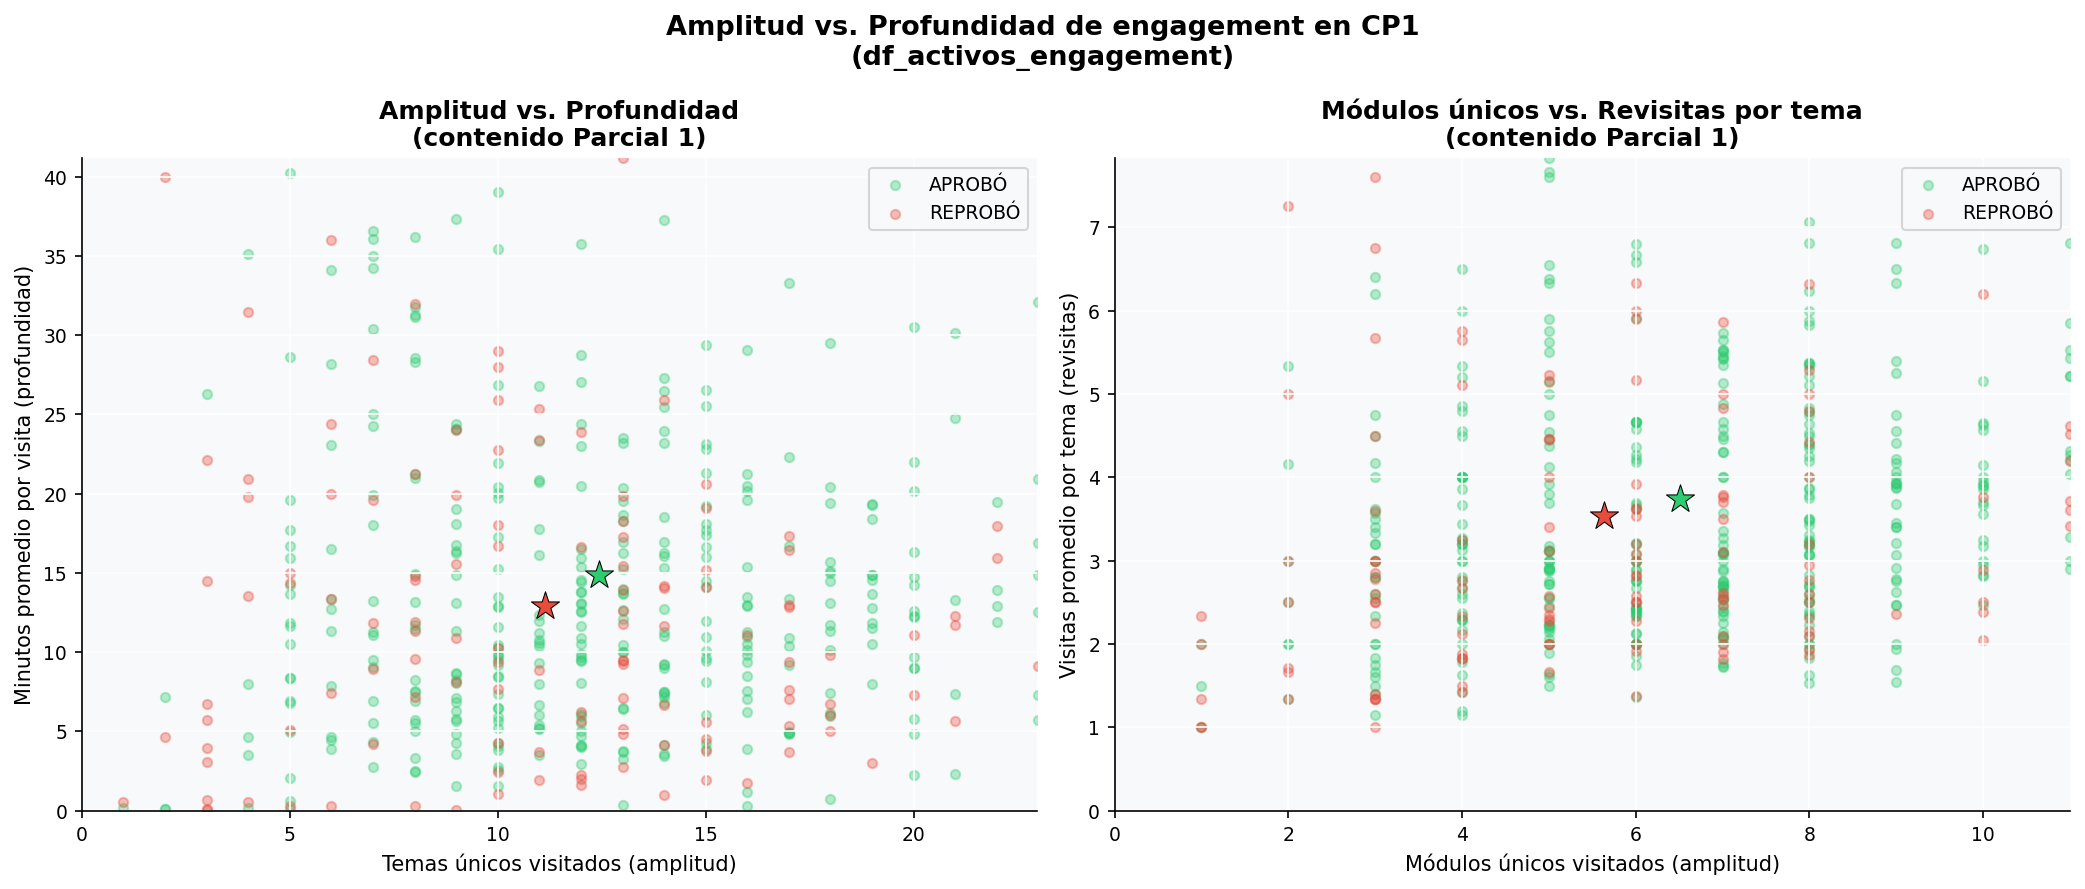

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Amplitud vs. Profundidad de engagement en CP1\n(df_activos_engagement)',
             fontsize=13, fontweight='bold')

# ── Panel A: Temas únicos vs Tiempo por visita ────────────────────────────────
ax = axes[0]
for estado in ['APROBÓ', 'REPROBÓ']:
    sub = df_ae[df_ae['estado'] == estado]
    ax.scatter(sub['parcial_1_temas_unicos'], sub['parcial_1_tiempo_por_visita'],
               alpha=0.35, s=20, color=PALETA_ESTADO[estado], label=estado)

ax.set_xlabel('Temas únicos visitados (amplitud)')
ax.set_ylabel('Minutos promedio por visita (profundidad)')
ax.set_title('Amplitud vs. Profundidad\n(contenido Parcial 1)', fontweight='bold')
ax.set_xlim(0, df_ae['parcial_1_temas_unicos'].quantile(0.97))
ax.set_ylim(0, df_ae['parcial_1_tiempo_por_visita'].quantile(0.97))
ax.legend()

# Medias de cada grupo
for estado in ['APROBÓ', 'REPROBÓ']:
    sub = df_ae[df_ae['estado'] == estado]
    ax.scatter(sub['parcial_1_temas_unicos'].mean(), sub['parcial_1_tiempo_por_visita'].mean(),
               s=200, marker='*', color=PALETA_ESTADO[estado], zorder=5, edgecolors='black', linewidths=0.5)

# ── Panel B: Módulos únicos vs Visitas por tema ───────────────────────────────
ax2 = axes[1]
for estado in ['APROBÓ', 'REPROBÓ']:
    sub = df_ae[df_ae['estado'] == estado]
    ax2.scatter(sub['parcial_1_modulos_unicos'], sub['parcial_1_visitas_por_tema'],
                alpha=0.35, s=20, color=PALETA_ESTADO[estado], label=estado)

ax2.set_xlabel('Módulos únicos visitados (amplitud)')
ax2.set_ylabel('Visitas promedio por tema (revisitas)')
ax2.set_title('Módulos únicos vs. Revisitas por tema\n(contenido Parcial 1)', fontweight='bold')
ax2.set_xlim(0, df_ae['parcial_1_modulos_unicos'].quantile(0.97))
ax2.set_ylim(0, df_ae['parcial_1_visitas_por_tema'].quantile(0.97))
ax2.legend()
for estado in ['APROBÓ', 'REPROBÓ']:
    sub = df_ae[df_ae['estado'] == estado]
    ax2.scatter(sub['parcial_1_modulos_unicos'].mean(), sub['parcial_1_visitas_por_tema'].mean(),
                s=200, marker='*', color=PALETA_ESTADO[estado], zorder=5, edgecolors='black', linewidths=0.5)

plt.tight_layout()
plt.savefig('../figures/03_amplitud_vs_profundidad.png', bbox_inches='tight', dpi=150)
plt.show()

### 4.2 Comparación de poder discriminante: AUC individual de cada variable
El AUC (Área bajo la Curva ROC) permite comparar de forma homogénea el poder discriminante de cada variable para predecir el resultado binario REPROBÓ/APROBÓ. Los parciales dominan claramente, pero dentro de las variables de engagement, los módulos únicos y el tiempo acumulado son los más informativos.

In [8]:
from sklearn.metrics import roc_auc_score

# Variables ordenadas por checkpoint y tipo
vars_auc = [
    # CP1 - Académicas
    ('parcial_1',                  'Parcial 1 [académica]',     'Académica'),
    # CP1 - Engagement
    ('engagement_hasta_p1',        'Tiempo hasta P1 (hrs) [CP1]', 'Engagement CP1'),
    ('parcial_1_modulos_unicos',   'Módulos únicos P1 [CP1]',    'Engagement CP1'),
    ('parcial_1_temas_unicos',     'Temas únicos P1 [CP1]',      'Engagement CP1'),
    ('parcial_1_visitas',          'Visitas P1 [CP1]',           'Engagement CP1'),
    ('parcial_1_visitas_por_tema', 'Visitas/tema P1 [CP1]',      'Engagement CP1'),
    ('parcial_1_tiempo_por_visita','Min/visita P1 [CP1]',        'Engagement CP1'),
    # CP2
    ('parcial_2',                  'Parcial 2 [académica]',      'Académica'),
    ('promedio_ams',               'Promedio AMs [académica]',   'Académica'),
    ('promedio_quices',            'Promedio Quices [académica]','Académica'),
    ('engagement_hasta_p2',        'Tiempo hasta P2 (hrs) [CP2]','Engagement CP2'),
    # Total
    ('total_modulos',              'Módulos totales [sem]',      'Engagement total'),
    ('total_temas',                'Temas totales [sem]',        'Engagement total'),
    ('total_tiempo_hrs',           'Tiempo total (hrs) [sem]',   'Engagement total'),
]

print("=" * 75)
print("AUC INDIVIDUAL POR VARIABLE (predictor de REPROBÓ)")
print("=" * 75)
print(f"{'Variable':<45} {'Tipo':<18} {'AUC':>6}")
print("-" * 75)

colores_tipo = {
    'Académica': '#2ecc71',
    'Engagement CP1': '#3498db',
    'Engagement CP2': '#9b59b6',
    'Engagement total': '#e67e22',
}

resultados_auc = []
y_bin = (df_ae['estado'] == 'REPROBÓ').astype(int)

for var, label, tipo in vars_auc:
    data = df_ae[['estado', var]].dropna()
    yb   = (data['estado'] == 'REPROBÓ').astype(int)
    try:
        auc = roc_auc_score(yb, -data[var])  # negativo: mayor valor = menor riesgo
        resultados_auc.append((var, label, tipo, auc))
        print(f"  {label:<43} {tipo:<18} {auc:>6.4f}")
    except:
        pass

print("-" * 75)
print("\nReferencia: AUC=0.5 (azar) | AUC=0.75 (objetivo proyecto) | AUC>0.80 (excelente)")

AUC INDIVIDUAL POR VARIABLE (predictor de REPROBÓ)
Variable                                      Tipo                  AUC
---------------------------------------------------------------------------
  Parcial 1 [académica]                       Académica          0.8144
  Tiempo hasta P1 (hrs) [CP1]                 Engagement CP1     0.6019
  Módulos únicos P1 [CP1]                     Engagement CP1     0.6013
  Temas únicos P1 [CP1]                       Engagement CP1     0.5670
  Visitas P1 [CP1]                            Engagement CP1     0.5749
  Visitas/tema P1 [CP1]                       Engagement CP1     0.5650
  Min/visita P1 [CP1]                         Engagement CP1     0.5623
  Parcial 2 [académica]                       Académica          0.8598
  Promedio AMs [académica]                    Académica          0.7275
  Promedio Quices [académica]                 Académica          0.8176
  Tiempo hasta P2 (hrs) [CP2]                 Engagement CP2     0.5977
  Módulos

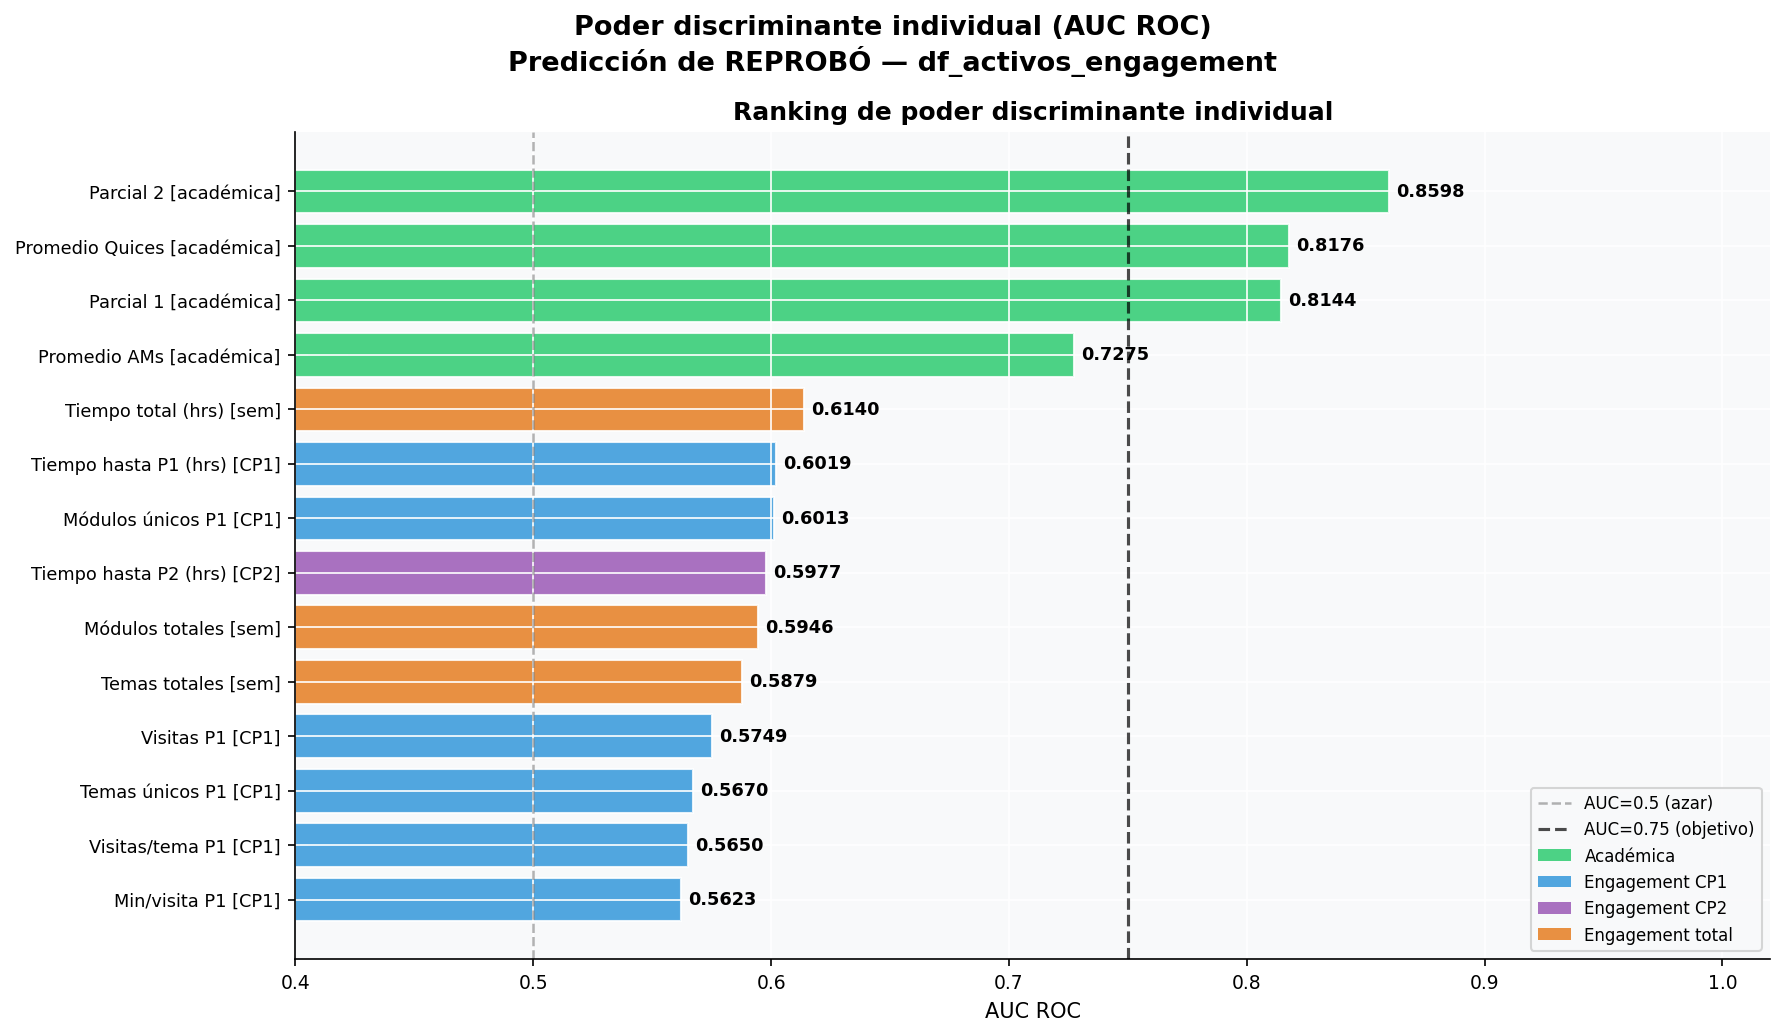

In [9]:
# ── Visualización: ranking AUC ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle('Poder discriminante individual (AUC ROC)\nPredicción de REPROBÓ — df_activos_engagement',
             fontsize=13, fontweight='bold')

# Ordenar por AUC
resultados_auc.sort(key=lambda x: x[3])
labels_plot = [r[1] for r in resultados_auc]
aucs_plot   = [r[3] for r in resultados_auc]
tipos_plot  = [r[2] for r in resultados_auc]
colors_plot = [colores_tipo[t] for t in tipos_plot]

bars = ax.barh(range(len(resultados_auc)), aucs_plot, color=colors_plot, alpha=0.85, edgecolor='white')
for i, (bar, auc) in enumerate(zip(bars, aucs_plot)):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{auc:.4f}', va='center', fontsize=8.5, fontweight='bold')

ax.axvline(0.5, color='gray', linestyle='--', linewidth=1.2, alpha=0.6, label='AUC=0.5 (azar)')
ax.axvline(0.75, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='AUC=0.75 (objetivo)')
ax.set_yticks(range(len(resultados_auc)))
ax.set_yticklabels(labels_plot, fontsize=8.5)
ax.set_xlabel('AUC ROC'); ax.set_xlim(0.4, 1.02)
ax.set_title('Ranking de poder discriminante individual', fontweight='bold')

# Leyenda de colores por tipo
for tipo, color in colores_tipo.items():
    ax.bar(0, 0, color=color, label=tipo, alpha=0.85)
ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('../figures/03_auc_individual_variables.png', bbox_inches='tight', dpi=150)
plt.show()

## Sección 5 — Engagement por Semestre y Era
El comportamiento de uso de la plataforma varía significativamente entre semestres. El formato antiguo (202320, 202410) muestra medianas de engagement más altas, posiblemente por la mayor madurez del curso en la plataforma o porque los estudiantes del formato antiguo dependían más de los recursos digitales al no tener AMs/quices en-clase que los anclasen.
## 5.1 Comparativa de engagement por semestre

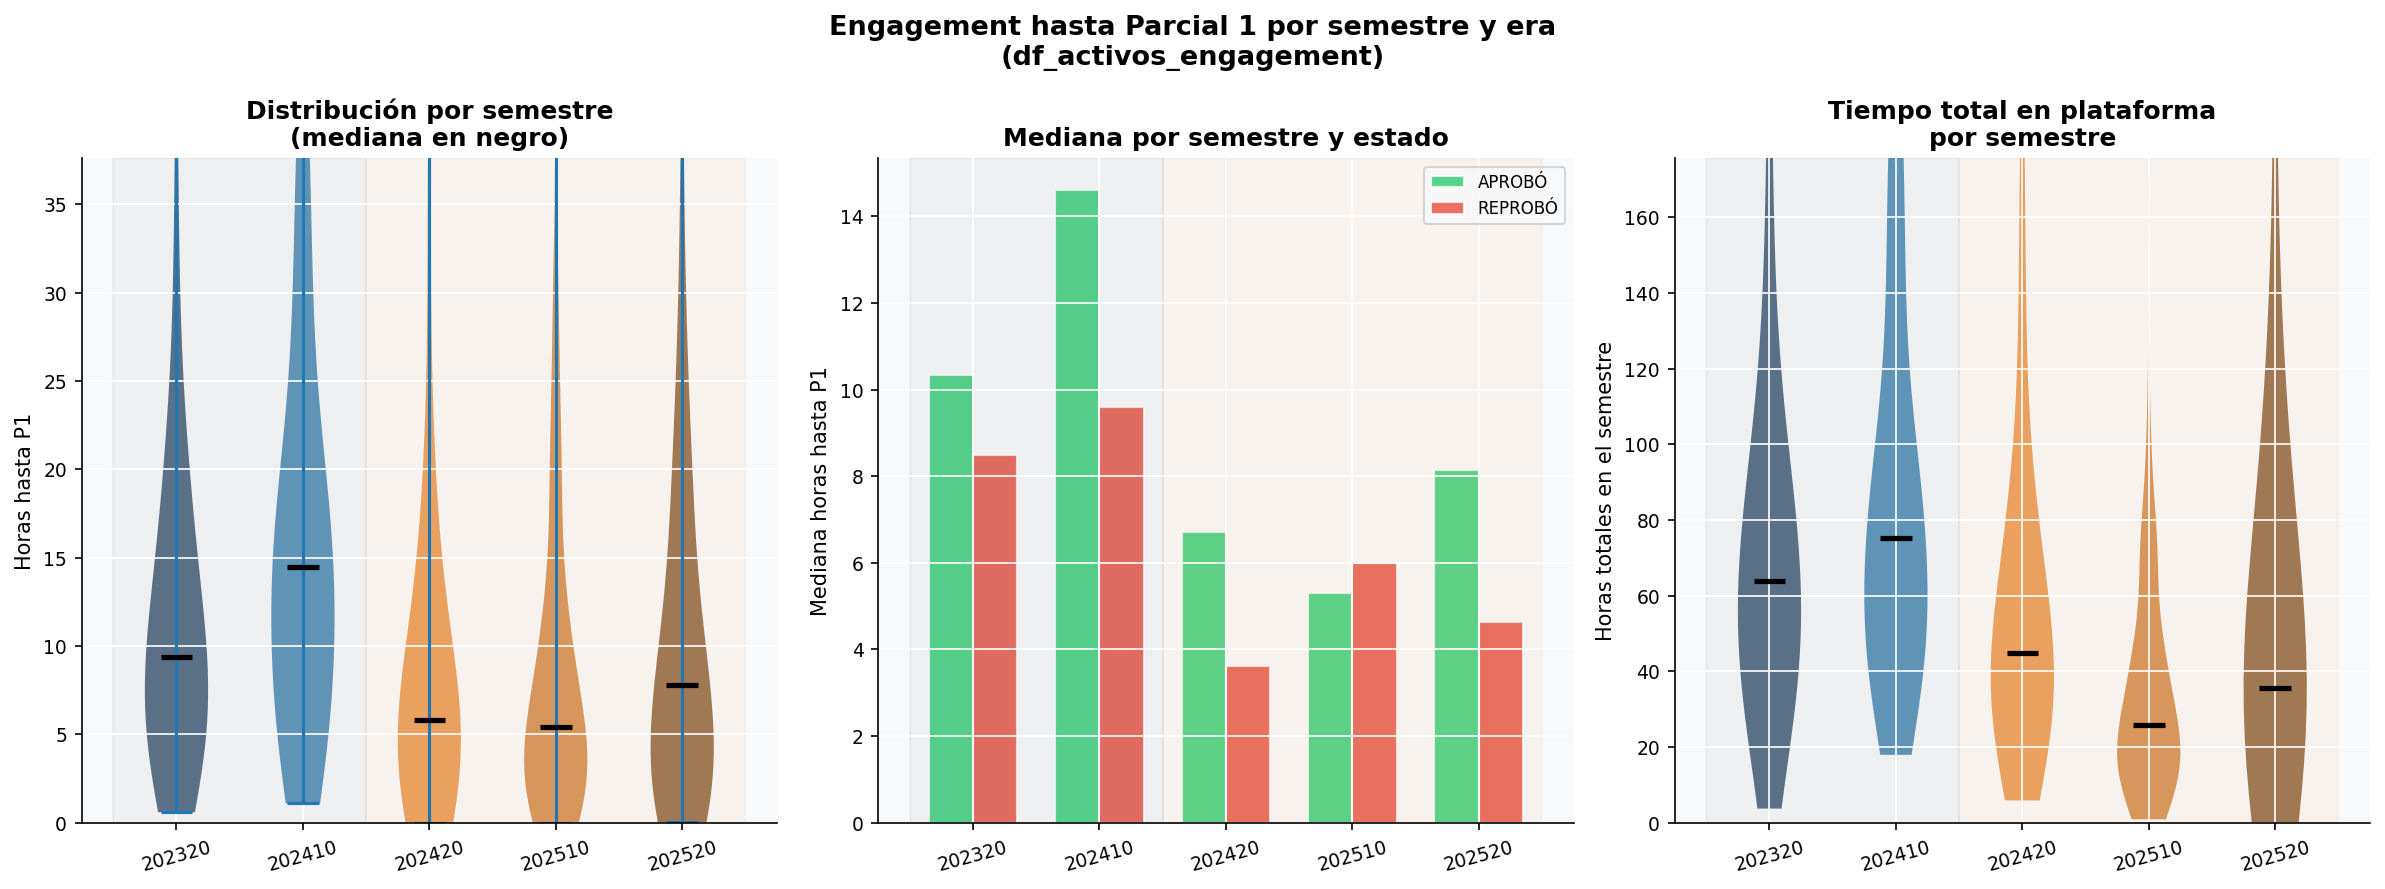

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Engagement hasta Parcial 1 por semestre y era\n(df_activos_engagement)',
             fontsize=13, fontweight='bold')

# ── Panel A: Boxplot por semestre ─────────────────────────────────────────────
ax = axes[0]
data_viol = [df_ae[df_ae['semestre']==s]['engagement_hasta_p1'].dropna().values for s in semestres]
parts = ax.violinplot(data_viol, positions=range(len(semestres)),
                      showmedians=True, showextrema=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(PALETA_SEMESTRE[semestres[i]]); pc.set_alpha(0.7)
parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2.5)

ax.set_xticks(range(len(semestres)))
ax.set_xticklabels([str(s) for s in semestres], rotation=15)
ax.set_ylabel('Horas hasta P1')
ax.set_ylim(0, df_ae['engagement_hasta_p1'].quantile(0.97))
ax.set_title('Distribución por semestre\n(mediana en negro)', fontweight='bold')
ax.axvspan(-0.5, 1.5, alpha=0.05, color=PALETA_ERA['formato_antiguo'])
ax.axvspan(1.5, 4.5, alpha=0.05, color=PALETA_ERA['formato_nuevo'])

# ── Panel B: APROBÓ vs REPROBÓ por semestre (medias) ─────────────────────────
ax2 = axes[1]
x = np.arange(len(semestres)); w = 0.35
for j, (estado, color) in enumerate([('APROBÓ', PALETA_ESTADO['APROBÓ']),
                                       ('REPROBÓ', PALETA_ESTADO['REPROBÓ'])]):
    meds = [df_ae[(df_ae['semestre']==s) & (df_ae['estado']==estado)]['engagement_hasta_p1'].median()
            for s in semestres]
    ax2.bar(x + j*w - w/2, meds, width=w, color=color, alpha=0.8, label=estado, edgecolor='white')

ax2.set_xticks(x); ax2.set_xticklabels([str(s) for s in semestres], rotation=15)
ax2.set_ylabel('Mediana horas hasta P1')
ax2.set_title('Mediana por semestre y estado', fontweight='bold')
ax2.legend(fontsize=8)
ax2.axvspan(-0.5, 1.5, alpha=0.05, color=PALETA_ERA['formato_antiguo'])
ax2.axvspan(1.5, 4.5, alpha=0.05, color=PALETA_ERA['formato_nuevo'])

# ── Panel C: Total tiempo semestre por semestre ───────────────────────────────
ax3 = axes[2]
data_viol3 = [df_ae[df_ae['semestre']==s]['total_tiempo_hrs'].dropna().values for s in semestres]
parts3 = ax3.violinplot(data_viol3, positions=range(len(semestres)),
                         showmedians=True, showextrema=False)
for i, pc in enumerate(parts3['bodies']):
    pc.set_facecolor(PALETA_SEMESTRE[semestres[i]]); pc.set_alpha(0.7)
parts3['cmedians'].set_color('black'); parts3['cmedians'].set_linewidth(2.5)

ax3.set_xticks(range(len(semestres)))
ax3.set_xticklabels([str(s) for s in semestres], rotation=15)
ax3.set_ylabel('Horas totales en el semestre')
ax3.set_ylim(0, df_ae['total_tiempo_hrs'].quantile(0.95))
ax3.set_title('Tiempo total en plataforma\npor semestre', fontweight='bold')
ax3.axvspan(-0.5, 1.5, alpha=0.05, color=PALETA_ERA['formato_antiguo'])
ax3.axvspan(1.5, 4.5, alpha=0.05, color=PALETA_ERA['formato_nuevo'])

plt.tight_layout()
plt.savefig('../figures/03_engagement_por_semestre.png', bbox_inches='tight', dpi=150)
plt.show()

## Sección 6 — Multicolinealidad entre Variables de Engagement
Antes de introducir las variables de engagement en los modelos predictivos, es crucial entender su estructura de correlaciones internas. Variables muy correlacionadas entre sí (multicolinealidad) aportan información redundante y pueden desestabilizar los modelos lineales.
El análisis revela que engagement_hasta_p1 y parcial_1_tiempo_hrs son perfectamente colineales (r=1.0) — son la misma variable bajo distintos nombres. La amplitud (temas, módulos) y el volumen (tiempo, visitas) están moderadamente correlacionados (r≈0.5-0.7), pero no al punto de ser redundantes.
## 6.1 Mapa de correlaciones entre features de engagement

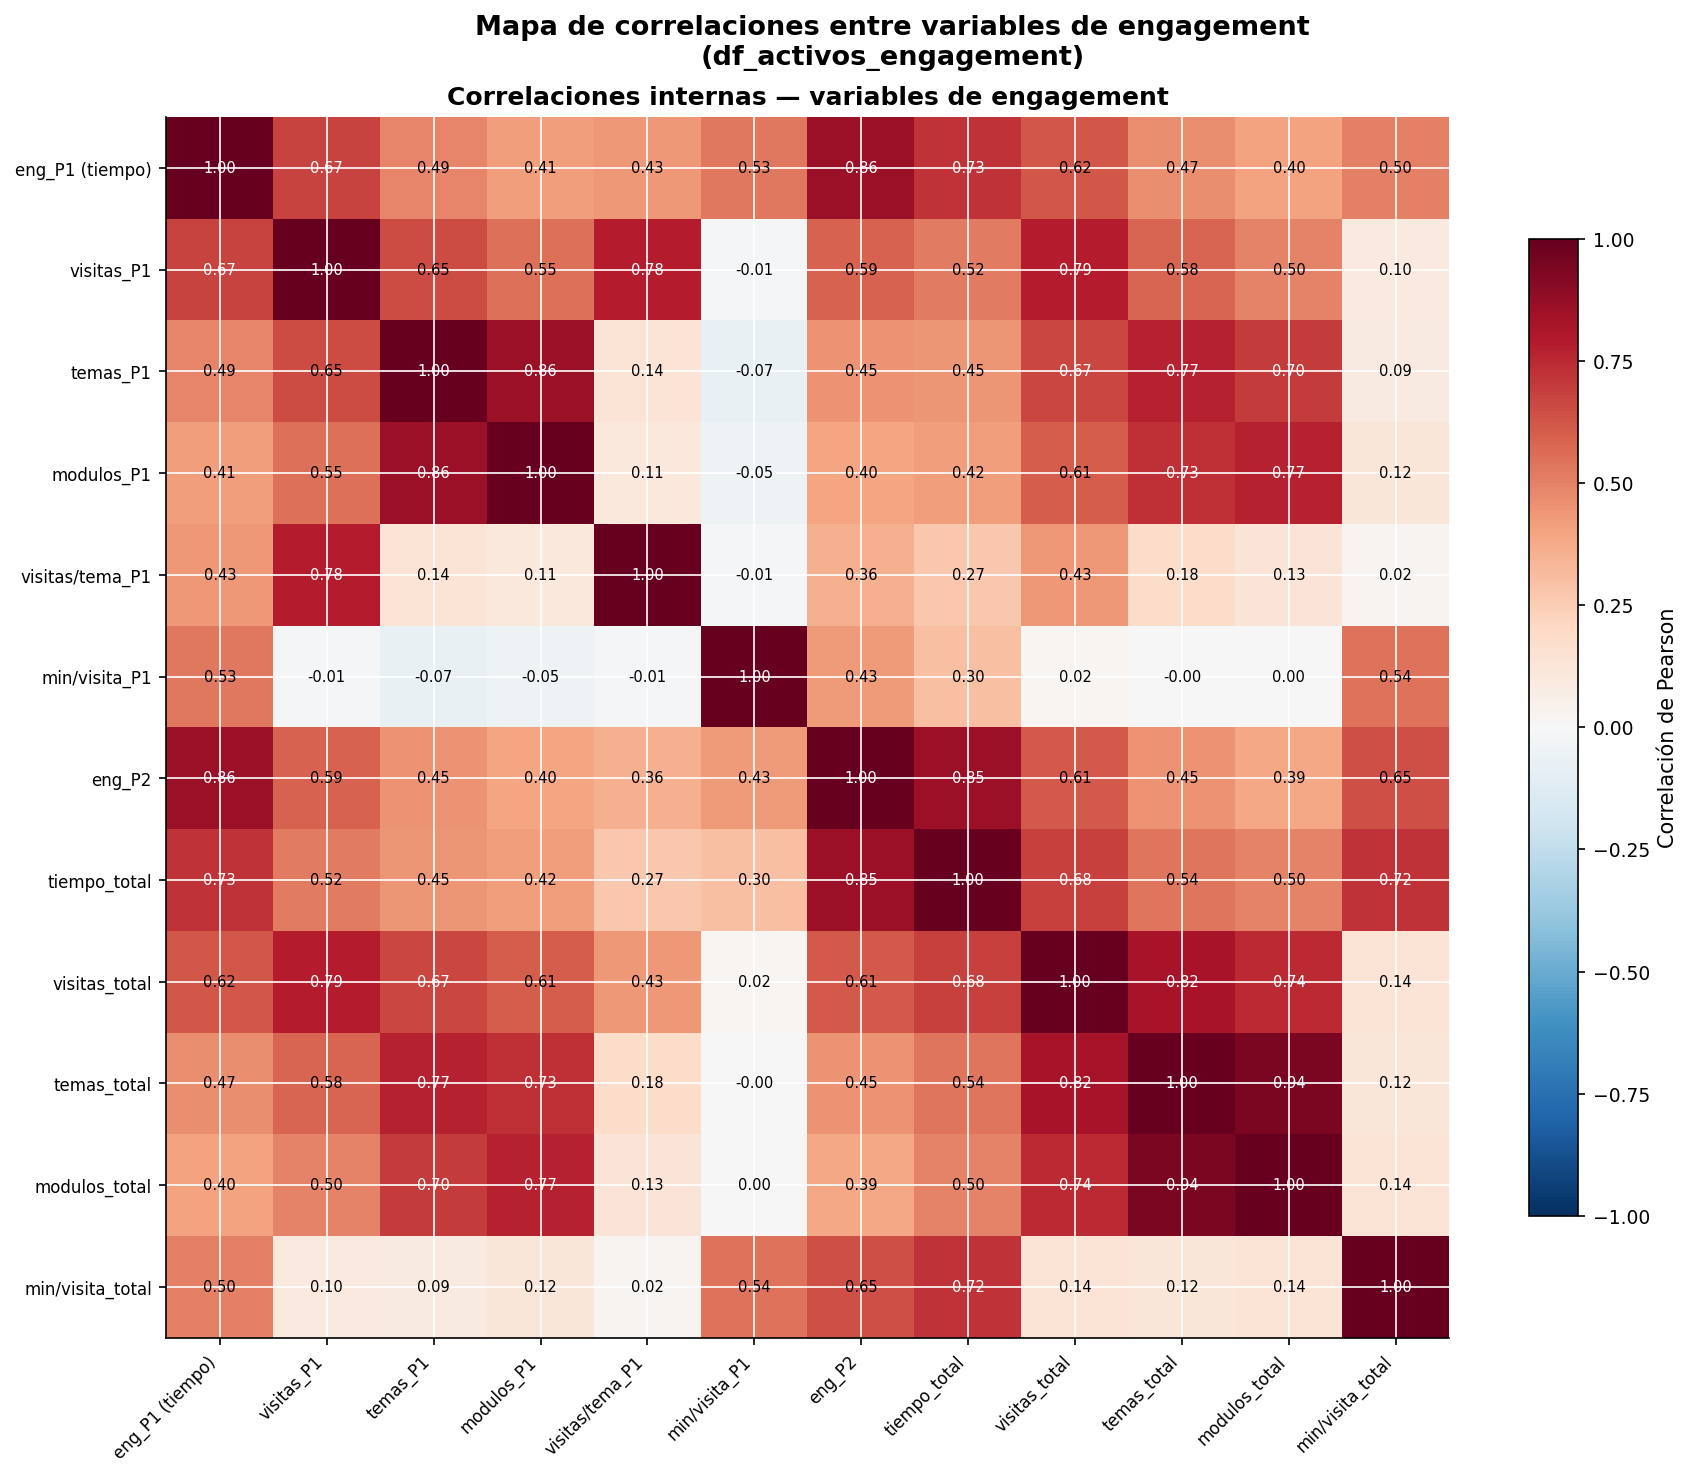


Pares con alta colinealidad (r > 0.85):
  eng_P1 (tiempo) ↔ eng_P2: r=0.864
  temas_P1 ↔ modulos_P1: r=0.861
  eng_P2 ↔ tiempo_total: r=0.852
  temas_total ↔ modulos_total: r=0.941

Implicación para modelado: elegir UNA variable de cada par colineal.
Sugerencia CP1: usar engagement_hasta_p1 + parcial_1_modulos_unicos (menor colinealidad r=0.41)


In [11]:
eng_feats_corr = [
    'engagement_hasta_p1',
    'parcial_1_visitas',
    'parcial_1_temas_unicos',
    'parcial_1_modulos_unicos',
    'parcial_1_visitas_por_tema',
    'parcial_1_tiempo_por_visita',
    'engagement_hasta_p2',
    'total_tiempo_hrs',
    'total_visitas',
    'total_temas',
    'total_modulos',
    'promedio_tiempo_por_visita',
]

corr_eng = df_ae[eng_feats_corr].corr().round(3)

fig, ax = plt.subplots(figsize=(12, 10))
fig.suptitle('Mapa de correlaciones entre variables de engagement\n(df_activos_engagement)',
             fontsize=13, fontweight='bold')

labels_short = [
    'eng_P1 (tiempo)', 'visitas_P1', 'temas_P1', 'modulos_P1',
    'visitas/tema_P1', 'min/visita_P1',
    'eng_P2', 'tiempo_total', 'visitas_total',
    'temas_total', 'modulos_total', 'min/visita_total'
]

im = ax.imshow(corr_eng.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8, label='Correlación de Pearson')

ax.set_xticks(range(len(labels_short))); ax.set_xticklabels(labels_short, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(labels_short))); ax.set_yticklabels(labels_short, fontsize=8)

# Anotaciones
for i in range(len(corr_eng)):
    for j in range(len(corr_eng)):
        v = corr_eng.values[i, j]
        color = 'white' if abs(v) > 0.65 else 'black'
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7, color=color)

ax.set_title('Correlaciones internas — variables de engagement', fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/03_correlaciones_engagement.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nPares con alta colinealidad (r > 0.85):")
for i in range(len(corr_eng)):
    for j in range(i+1, len(corr_eng)):
        v = corr_eng.values[i, j]
        if abs(v) > 0.85:
            print(f"  {labels_short[i]} ↔ {labels_short[j]}: r={v:.3f}")
print("\nImplicación para modelado: elegir UNA variable de cada par colineal.")
print("Sugerencia CP1: usar engagement_hasta_p1 + parcial_1_modulos_unicos (menor colinealidad r=0.41)")

##  7 — Variables de Actividades Magistrales en Plataforma
Las variables actividades_n_realizadas, actividades_tiempo_total y actividades_visitas_total capturan el engagement con el contenido de las actividades magistrales en Bloque Neón (preparación previa o consulta posterior), no el desempeño en las AMs presenciales.
Un hallazgo notable: ninguna de estas tres variables discrimina significativamente entre APROBÓ y REPROBÓ (Mann-Whitney p>0.2). Esto sugiere que el engagement digital con las actividades magistrales no predice el rendimiento, posiblemente porque las AMs se realizan presencialmente y el material digital es consultado de forma similar por todos los estudiantes.

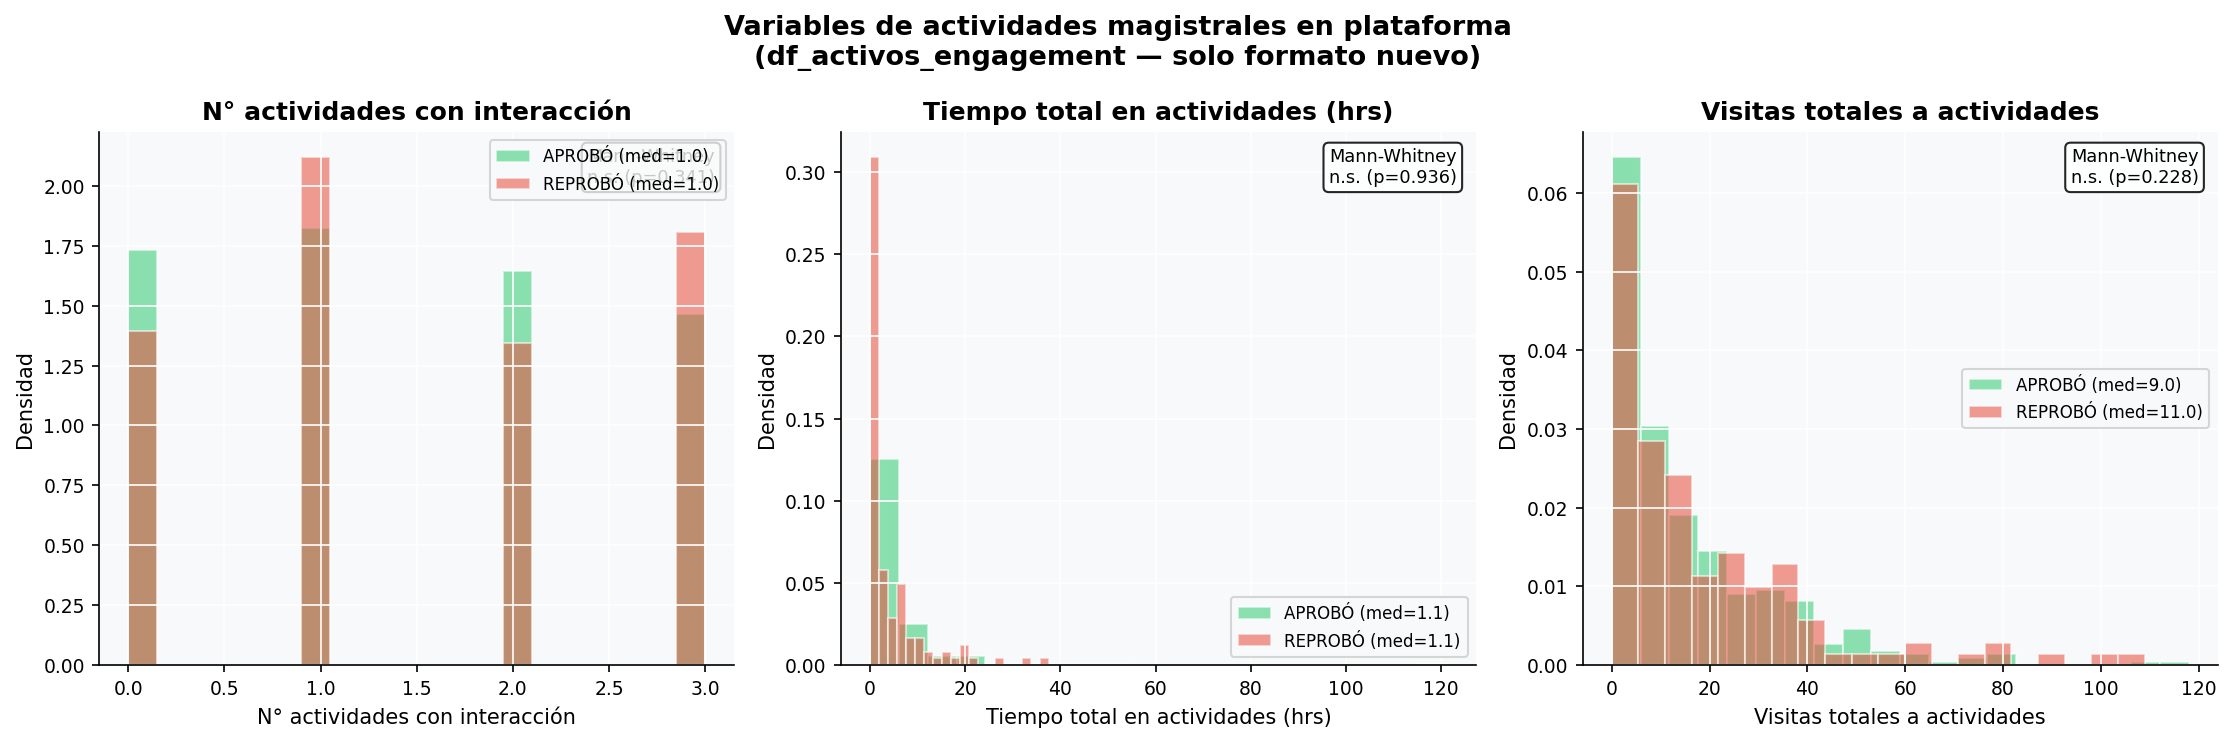


Conclusión: Las variables de actividades magistrales en plataforma NO tienen
poder discriminante significativo (p>0.2 en los tres casos).
Recomendación: EXCLUIR de los modelos CP1/CP2 como features independientes.
Razón: el engagement digital con AMs refleja consulta indiscriminada, no aprendizaje.


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Variables de actividades magistrales en plataforma\n(df_activos_engagement — solo formato nuevo)',
             fontsize=13, fontweight='bold')

vars_act = [
    ('actividades_n_realizadas',   'N° actividades con interacción'),
    ('actividades_tiempo_total',   'Tiempo total en actividades (hrs)'),
    ('actividades_visitas_total',  'Visitas totales a actividades'),
]

for ax, (var, xlabel) in zip(axes, vars_act):
    for estado in ['APROBÓ', 'REPROBÓ']:
        data = df_ae[df_ae['estado']==estado][var].dropna()
        if len(data) < 5: continue
        ax.hist(data, bins=20, alpha=0.55, color=PALETA_ESTADO[estado],
                label=f'{estado} (med={data.median():.1f})',
                edgecolor='white', density=True)

    apro  = df_ae[df_ae['estado']=='APROBÓ'][var].dropna()
    repr_ = df_ae[df_ae['estado']=='REPROBÓ'][var].dropna()
    if len(apro)>5 and len(repr_)>5:
        u, p = mannwhitneyu(apro, repr_, alternative='two-sided')
        sig  = '* p<0.05' if p<0.05 else f'n.s. (p={p:.3f})'
        ax.text(0.97, 0.97, f'Mann-Whitney\n{sig}',
                transform=ax.transAxes, va='top', ha='right', fontsize=8.5,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

    ax.set_xlabel(xlabel); ax.set_ylabel('Densidad')
    ax.set_title(xlabel, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../figures/03_actividades_engagement.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nConclusión: Las variables de actividades magistrales en plataforma NO tienen")
print("poder discriminante significativo (p>0.2 en los tres casos).")
print("Recomendación: EXCLUIR de los modelos CP1/CP2 como features independientes.")
print("Razón: el engagement digital con AMs refleja consulta indiscriminada, no aprendizaje.")